In [17]:
import pandas as pd
import numpy as np 
import sys

#added by Tsach
import pymatgen
from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)

import matplotlib.pyplot as plt
import ast
import os

In [18]:
folder_dir = "/home/gridsan/tmackey/cdvae/data/mp_20/"
df_train = pd.read_csv(folder_dir + 'train.csv')
df_val = pd.read_csv(folder_dir + 'val.csv')
df_test = pd.read_csv(folder_dir + 'test.csv')

In [21]:
df_train.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,material_id,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,TsachID,disc_sim_xrd,lattice_system
0,0,0,37228,mp-1221227,-1.637460,0.2133,Na3MnCoNiO6,0.043001,"['Co', 'Mn', 'Na', 'Ni', 'O']",# generated using pymatgen\ndata_Na3MnCoNiO6\n...,8,DiffractionPattern\n$2\Theta$: [11.87011609 16...,"[11.87011609469122, 16.52069689929858, 17.1482...","[0.464671693703146, 94.05248185142216, 0.72569...","[11, 11, 11, 25, 27, 28, 8, 8, 8, 8, 8, 8]",NaNaNaMnCoNiOOOOOO7.97762767.97762765.63711377...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,0.0
1,1,1,19480,mp-974729,-0.314759,0.0000,Nd(Al2Cu)4,0.000000,"['Al', 'Cu', 'Nd']",# generated using pymatgen\ndata_Nd(Al2Cu)4\n_...,139,DiffractionPattern\n$2\Theta$: [14.07069605 19...,"[14.070696049844747, 19.775602977923736, 19.94...","[29.452478536673507, 29.524371989407847, 12.11...","[60, 13, 13, 13, 13, 13, 13, 13, 13, 29, 29, 2...",NdAlAlAlAlAlAlAlAlCuCuCuCu6.80986366.80986366....,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,0.0
2,2,2,29624,mp-1185360,-0.193761,0.0000,LiMnIr2,0.018075,"['Ir', 'Li', 'Mn']",# generated using pymatgen\ndata_LiMnIr2\n_sym...,225,DiffractionPattern\n$2\Theta$: [26.20871065 30...,"[26.2087106549449, 30.353774524330394, 43.4609...","[3.6250325610399834, 68.2501747275368, 100.0, ...","[3, 25, 77, 77]",LiMnIrIr4.16442344.16442344.164423460.060.060.0,[ 0. 0. 0. 0. ...,4.0
3,3,3,38633,mp-1188861,-0.584694,3.8556,LiCSN,0.048847,"['C', 'Li', 'N', 'S']",# generated using pymatgen\ndata_LiCSN\n_symme...,62,DiffractionPattern\n$2\Theta$: [14.35172042 18...,"[14.351720419152775, 18.084725325124687, 21.99...","[9.98753987807856, 12.13654435473029, 1.800790...","[3, 3, 3, 3, 6, 6, 6, 6, 16, 16, 16, 16, 7, 7,...",LiLiLiLiCCCCSSSSNNNN3.8587835.34539612.3430919...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,2.0
4,4,4,10889,mp-677272,-2.474759,0.4707,La2EuS4,0.000000,"['Eu', 'La', 'S']",# generated using pymatgen\ndata_La2EuS4\n_sym...,122,DiffractionPattern\n$2\Theta$: [14.32156225 20...,"[14.32156225226108, 20.229215345610065, 24.873...","[0.4719172724252014, 0.09181220173027804, 100....","[57, 57, 57, 57, 63, 63, 16, 16, 16, 16, 16, 1...",LaLaLaLaEuEuSSSSSSSS7.5841897.5841897.58418910...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,0.0


In [22]:
df_train.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,material_id,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,TsachID,disc_sim_xrd,lattice_system
0,0,0,37228,mp-1221227,-1.637460,0.2133,Na3MnCoNiO6,0.043001,"['Co', 'Mn', 'Na', 'Ni', 'O']",# generated using pymatgen\ndata_Na3MnCoNiO6\n...,8,DiffractionPattern\n$2\Theta$: [11.87011609 16...,"[11.87011609469122, 16.52069689929858, 17.1482...","[0.464671693703146, 94.05248185142216, 0.72569...","[11, 11, 11, 25, 27, 28, 8, 8, 8, 8, 8, 8]",NaNaNaMnCoNiOOOOOO7.97762767.97762765.63711377...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,0.0
1,1,1,19480,mp-974729,-0.314759,0.0000,Nd(Al2Cu)4,0.000000,"['Al', 'Cu', 'Nd']",# generated using pymatgen\ndata_Nd(Al2Cu)4\n_...,139,DiffractionPattern\n$2\Theta$: [14.07069605 19...,"[14.070696049844747, 19.775602977923736, 19.94...","[29.452478536673507, 29.524371989407847, 12.11...","[60, 13, 13, 13, 13, 13, 13, 13, 13, 29, 29, 2...",NdAlAlAlAlAlAlAlAlCuCuCuCu6.80986366.80986366....,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,0.0
2,2,2,29624,mp-1185360,-0.193761,0.0000,LiMnIr2,0.018075,"['Ir', 'Li', 'Mn']",# generated using pymatgen\ndata_LiMnIr2\n_sym...,225,DiffractionPattern\n$2\Theta$: [26.20871065 30...,"[26.2087106549449, 30.353774524330394, 43.4609...","[3.6250325610399834, 68.2501747275368, 100.0, ...","[3, 25, 77, 77]",LiMnIrIr4.16442344.16442344.164423460.060.060.0,[ 0. 0. 0. 0. ...,4.0
3,3,3,38633,mp-1188861,-0.584694,3.8556,LiCSN,0.048847,"['C', 'Li', 'N', 'S']",# generated using pymatgen\ndata_LiCSN\n_symme...,62,DiffractionPattern\n$2\Theta$: [14.35172042 18...,"[14.351720419152775, 18.084725325124687, 21.99...","[9.98753987807856, 12.13654435473029, 1.800790...","[3, 3, 3, 3, 6, 6, 6, 6, 16, 16, 16, 16, 7, 7,...",LiLiLiLiCCCCSSSSNNNN3.8587835.34539612.3430919...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,2.0
4,4,4,10889,mp-677272,-2.474759,0.4707,La2EuS4,0.000000,"['Eu', 'La', 'S']",# generated using pymatgen\ndata_La2EuS4\n_sym...,122,DiffractionPattern\n$2\Theta$: [14.32156225 20...,"[14.32156225226108, 20.229215345610065, 24.873...","[0.4719172724252014, 0.09181220173027804, 100....","[57, 57, 57, 57, 63, 63, 16, 16, 16, 16, 16, 1...",LaLaLaLaEuEuSSSSSSSS7.5841897.5841897.58418910...,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,0.0


In [23]:
# Assuming df is your dataframe
# Convert string representations back to lists
df_train['xrd_peak_locations'] = df_train['xrd_peak_locations'].apply(ast.literal_eval)
df_train['xrd_peak_intensities'] = df_train['xrd_peak_intensities'].apply(ast.literal_eval)

In [24]:
sampled_df = df_train.sample(n=1000, random_state=42)

In [25]:
sampled_df['xrd_peak_intensities'].iloc[100]

[0.04436338609219944,
 0.15788757123931235,
 0.10740958932551327,
 2.1968466456129723,
 39.55816433968184,
 92.0556699431746,
 12.042685630595372,
 100.0,
 15.16943087323673,
 78.04062927765617,
 11.44587519818312,
 11.471208919377412,
 0.24134196916307749,
 0.1578184460759798,
 0.20915307266036057,
 0.25396078813086975,
 3.8735208742007137,
 1.6341106493195112,
 0.28216655455989886,
 7.3723016108756925,
 5.496823807588077,
 0.12465259335744076,
 33.710858227558866,
 23.36767837855606,
 4.44906918073787,
 32.4633469172681,
 8.271263797838273,
 0.08856574528142135,
 26.063853358284327,
 0.10093201504446482,
 0.003454110235876629,
 0.07987513353279901,
 12.780372251411375,
 0.023023536794287956,
 3.573809339928252,
 1.9517625511731924,
 0.24469204905502132,
 15.974496901767491,
 0.05346971080729991,
 1.303660278123111,
 9.571947845184726,
 3.1500746952380636,
 0.16003613771193112,
 8.853233430832486,
 2.8565998851333116,
 1.4955772413911412,
 3.1281130233842,
 5.1395559769664905]

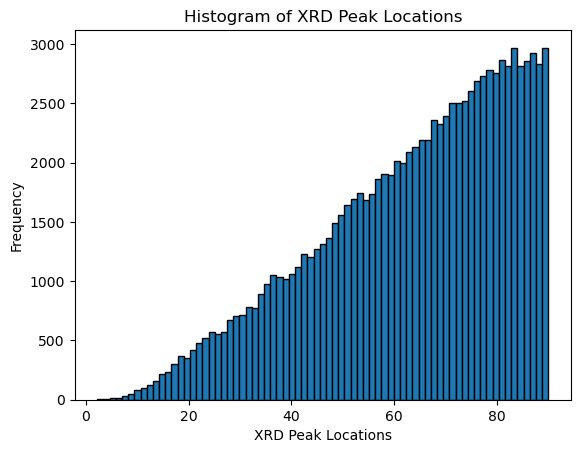

In [26]:
#the two important parameters that we need to decide upon when making a discrete simulated diffraction pattern 
#are the bounds and intervals of the pattern 
#to find the bounds, we need to pick a range that contains most of the peaks 
all_values = [value for sublist in sampled_df['xrd_peak_locations'] for value in sublist]

# Plot histogram
plt.hist(all_values, bins='auto', edgecolor='black')
plt.xlabel('XRD Peak Locations')
plt.ylabel('Frequency')
plt.title('Histogram of XRD Peak Locations')
plt.show()

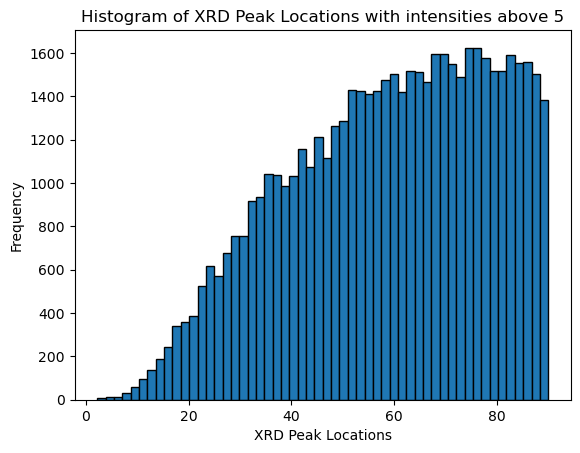

In [27]:
# Assuming 'xrd_peak_intensities' is the other column
all_values = [loc for (loc_list, int_list) in zip(sampled_df['xrd_peak_locations'], sampled_df['xrd_peak_intensities']) 
              for (loc, intensity) in zip(loc_list, int_list) if intensity > 1]

# Plot histogram
plt.hist(all_values, bins='auto', edgecolor='black')
plt.xlabel('XRD Peak Locations')
plt.ylabel('Frequency')
plt.title('Histogram of XRD Peak Locations with intensities above 5')
plt.show()

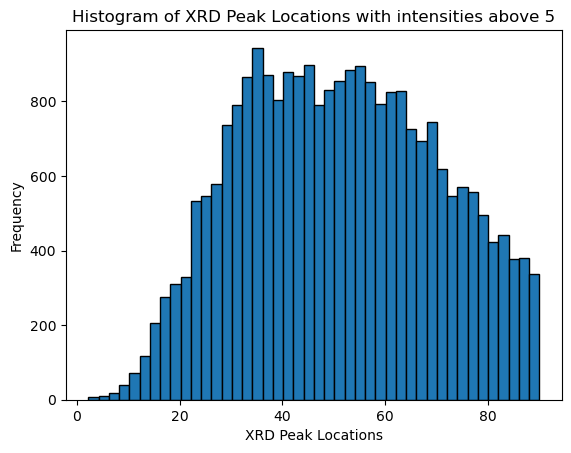

In [28]:
# Assuming 'xrd_peak_intensities' is the other column
all_values = [loc for (loc_list, int_list) in zip(sampled_df['xrd_peak_locations'], sampled_df['xrd_peak_intensities']) 
              for (loc, intensity) in zip(loc_list, int_list) if intensity > 5]

# Plot histogram
plt.hist(all_values, bins='auto', edgecolor='black')
plt.xlabel('XRD Peak Locations')
plt.ylabel('Frequency')
plt.title('Histogram of XRD Peak Locations with intensities above 5')
plt.show()

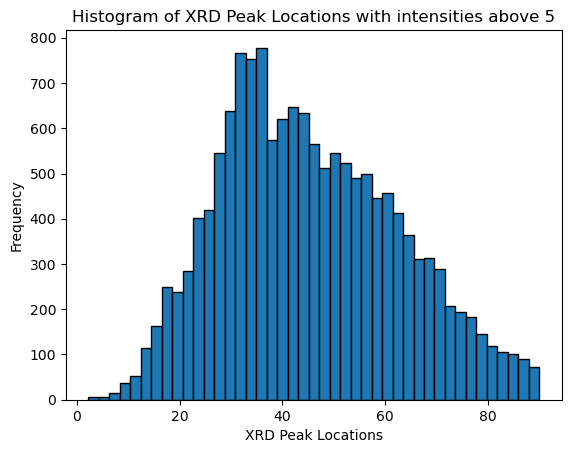

In [29]:
# Assuming 'xrd_peak_intensities' is the other column
all_values = [loc for (loc_list, int_list) in zip(sampled_df['xrd_peak_locations'], sampled_df['xrd_peak_intensities']) 
              for (loc, intensity) in zip(loc_list, int_list) if intensity > 10]

# Plot histogram
plt.hist(all_values, bins='auto', edgecolor='black')
plt.xlabel('XRD Peak Locations')
plt.ylabel('Frequency')
plt.title('Histogram of XRD Peak Locations with intensities above 5')
plt.show()

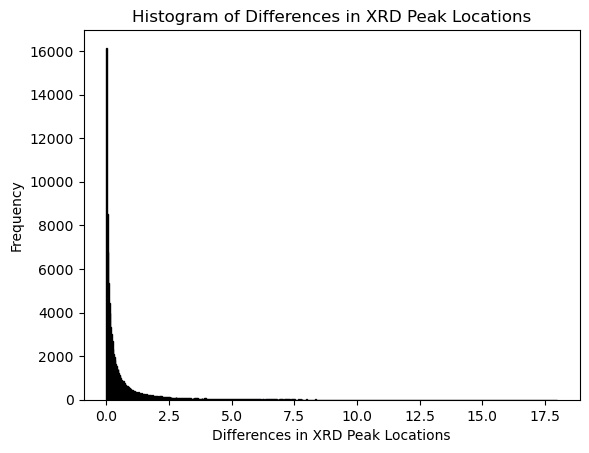

In [30]:
deltas = [loc_list[i+1] - loc_list[i] for loc_list in sampled_df['xrd_peak_locations'] for i in range(len(loc_list)-1)]

# Plot histogram
plt.hist(deltas, bins='auto', edgecolor='black')
plt.xlabel('Differences in XRD Peak Locations')
plt.ylabel('Frequency')
plt.title('Histogram of Differences in XRD Peak Locations')
plt.show()

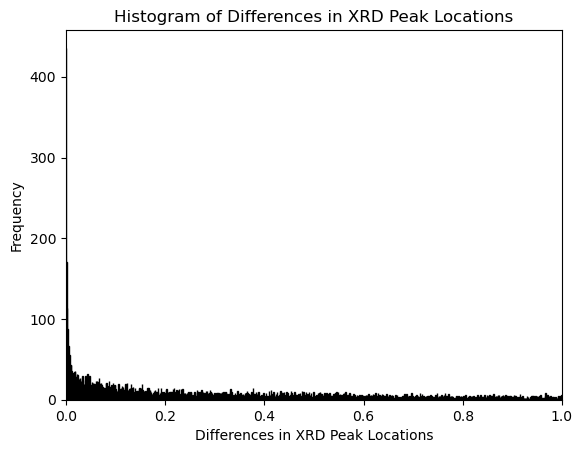

In [31]:
deltas = []

# Loop over rows in the sampled dataframe
for _, row in sampled_df.iterrows():
    loc_list = row['xrd_peak_locations']
    int_list = row['xrd_peak_intensities']
    
    minimum = 5

    # Loop over values in the current 'xrd_peak_locations' list
    for i in range(len(loc_list) - 1):
        # Check if both are greater than 5
        if int_list[i] > minimum and int_list[i+1] > minimum:
            # Compute the difference and append it to the deltas list
            delta = loc_list[i+1] - loc_list[i]
            deltas.append(delta)
            
# Plot histogram
plt.hist(deltas, bins=1000, edgecolor='black', range=(0, 1))
plt.xlabel('Differences in XRD Peak Locations')
plt.ylabel('Frequency')
plt.title('Histogram of Differences in XRD Peak Locations')
plt.xlim(0, 1)
plt.show()

Unfortunately, while this gives us information about the frequencies and spacing of the peaks, it doesn't really tell us anything about how much information is in the peaks themselves. A good starting guess for a bound and interval over the two theta values in this materials project data is (5, 75) with 0.35 intervals.

In [32]:
#let's pull out the diffraction patterns ahead of time 
def simulate_xrd(peak_locations, peak_intensities, lower_bound = 5, upper_bound = 75, dimensions = 200):
    interval =  (upper_bound - lower_bound)/dimensions
    sim_positions = np.arange(lower_bound, upper_bound, interval)
    # Create an empty intensity array for the simulation
    sim_intensities = np.zeros_like(sim_positions)
    
    # Loop over all simulated positions
    for i, pos in enumerate(sim_positions):
        # Find peak locations within 0.25° of the current simulated position
        close_peaks = [(loc, intensity) for loc, intensity in zip(peak_locations, peak_intensities) if abs(loc - pos) <= interval/2]
        
        # If there are close peaks, sum the intensities among those peaks
        if close_peaks:
            intensities = np.array([intensity for loc, intensity in close_peaks])
            sim_intensities[i] = np.sum(intensities)
    
    sim_intensities = 100*sim_intensities / max(sim_intensities)
    
    return sim_intensities

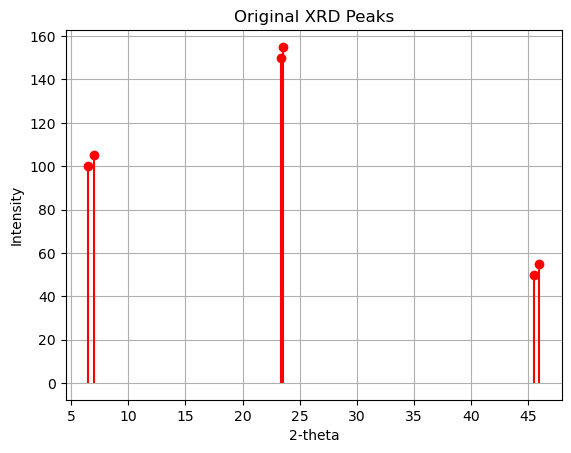

In [33]:
# Sample peak locations and intensities
peak_locations = np.array([6.5, 7.0, 23.4, 23.5, 45.5, 46.0])
peak_intensities = np.array([100, 105, 150, 155, 50, 55])

# Plotting the original peak data
plt.stem(peak_locations, peak_intensities, markerfmt='ro', basefmt=" ", linefmt='-r')
plt.xlabel('2-theta')
plt.ylabel('Intensity')
plt.title('Original XRD Peaks')
plt.grid(True)
plt.show()

In [34]:
results = simulate_xrd(peak_locations, peak_intensities)

In [35]:
print(len(results))

200


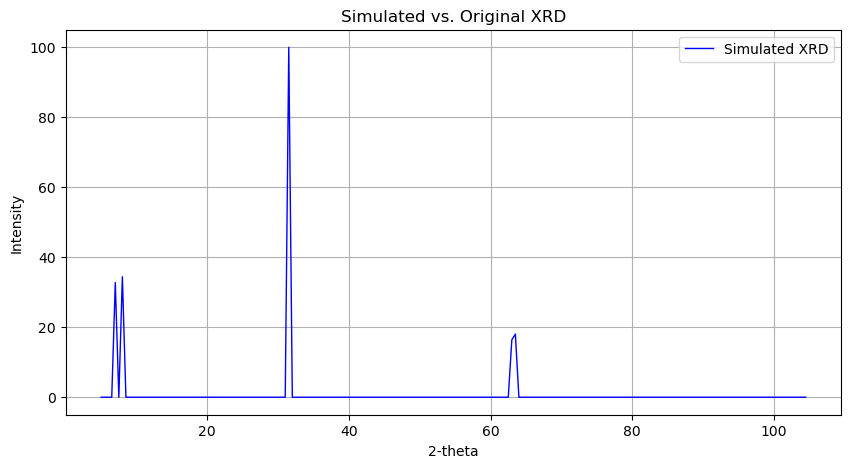

In [36]:
# Plotting
plt.figure(figsize=(10,5))

# Plot original data
#plt.stem(peak_locations, peak_intensities, markerfmt='ro', basefmt=" ", linefmt='-r', label='Original Peaks')

# Plot simulated data
plt.plot(np.arange(len(results))*0.5+5, results, label='Simulated XRD', color='blue', linestyle='-', linewidth=1)

plt.xlabel('2-theta')
plt.ylabel('Intensity')
plt.title('Simulated vs. Original XRD')
plt.grid(True)
plt.legend()
plt.show()

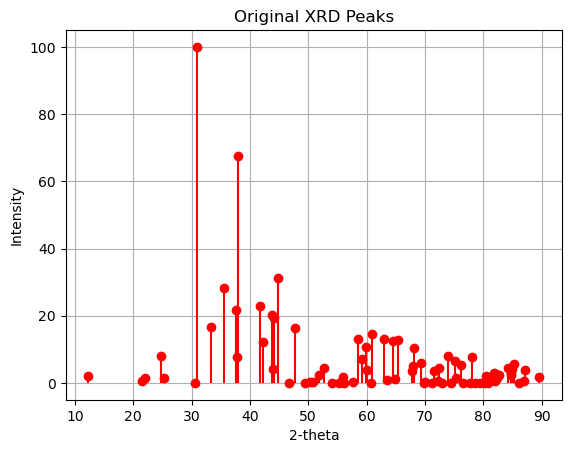

In [37]:
# Sample peak locations and intensities
peak_locations = sampled_df.xrd_peak_locations.iloc[0]
peak_intensities = sampled_df.xrd_peak_intensities.iloc[0]

# Plotting the original peak data
plt.stem(peak_locations, peak_intensities, markerfmt='ro', basefmt=" ", linefmt='-r')
plt.xlabel('2-theta')
plt.ylabel('Intensity')
plt.title('Original XRD Peaks')
plt.grid(True)
plt.show()

In [38]:
results = simulate_xrd(peak_locations, peak_intensities)

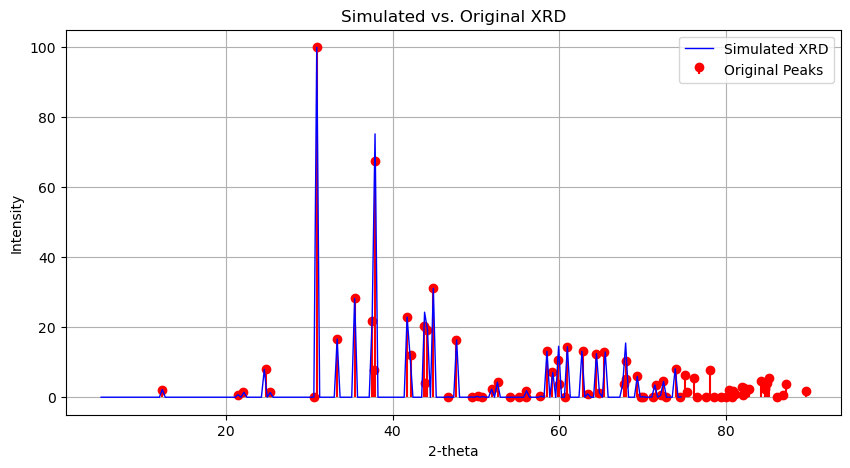

In [39]:
# Plotting
plt.figure(figsize=(10,5))

# Plot original data
plt.stem(peak_locations, peak_intensities, markerfmt='ro', basefmt=" ", linefmt='-r', label='Original Peaks')

# Plot simulated data
plt.plot(np.arange(len(results))*0.35+5, results, label='Simulated XRD', color='blue', linestyle='-', linewidth=1)

plt.xlabel('2-theta')
plt.ylabel('Intensity')
plt.title('Simulated vs. Original XRD')
plt.grid(True)
plt.legend()
plt.show()

In [40]:
sampled_df['disc_sim_xrd'] = sampled_df.apply(lambda row: simulate_xrd(row['xrd_peak_locations'], row['xrd_peak_intensities']), axis=1)

In [41]:
results = sampled_df['disc_sim_xrd'].iloc[0]

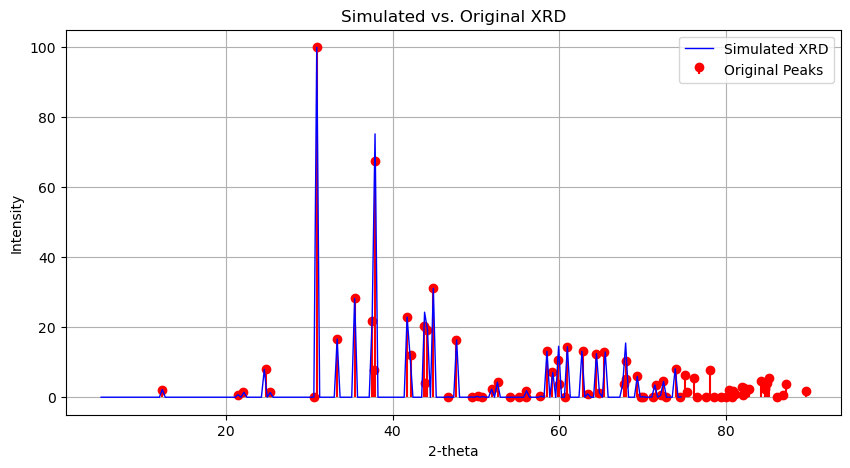

In [42]:
# Plotting
plt.figure(figsize=(10,5))

# Plot original data
plt.stem(peak_locations, peak_intensities, markerfmt='ro', basefmt=" ", linefmt='-r', label='Original Peaks')

# Plot simulated data
plt.plot(np.arange(len(results))*0.35+5, results, label='Simulated XRD', color='blue', linestyle='-', linewidth=1)

plt.xlabel('2-theta')
plt.ylabel('Intensity')
plt.title('Simulated vs. Original XRD')
plt.grid(True)
plt.legend()
plt.show()

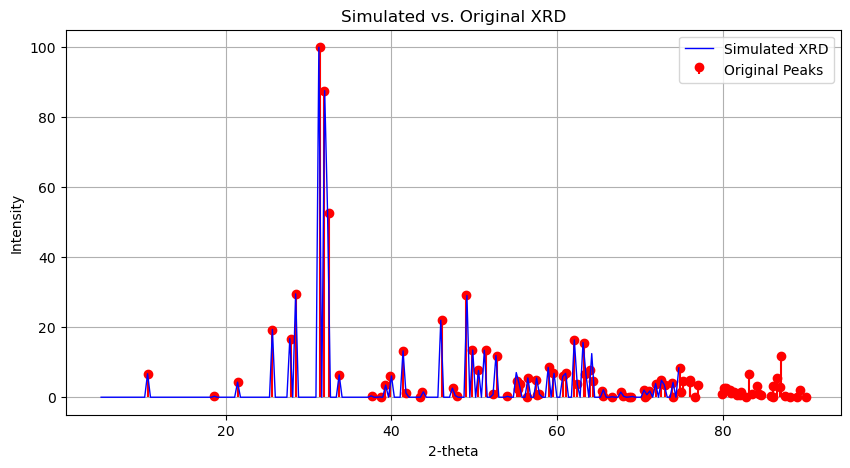

In [43]:
results = sampled_df['disc_sim_xrd'].iloc[1]

# Plotting
plt.figure(figsize=(10,5))

plt.stem(sampled_df['xrd_peak_locations'].iloc[1], sampled_df['xrd_peak_intensities'].iloc[1], markerfmt='ro', basefmt=" ", linefmt='-r', label='Original Peaks')

# Plot simulated data
plt.plot(np.arange(len(results))*0.35+5, results, label='Simulated XRD', color='blue', linestyle='-', linewidth=1)

plt.xlabel('2-theta')
plt.ylabel('Intensity')
plt.title('Simulated vs. Original XRD')
plt.grid(True)
plt.legend()
plt.show()

In [49]:
folder_dir = "/home/gridsan/tmackey/cdvae/data/mp_20/"

filenames = [folder_dir + 'train.csv',
              folder_dir + 'val.csv',
              folder_dir + 'test.csv']

for filename in filenames: 
    new_filename = filename[0:-4] + "_maxed_disc_sim_xrd.csv"
    print(new_filename)
    os.rename(filename, new_filename)
    

In [48]:
# Apply the function to the test and val datasets for the mp_20 data
df_train['disc_sim_xrd'] = df_train.apply(lambda row: simulate_xrd(row['xrd_peak_locations'], row['xrd_peak_intensities']), axis=1)
df_val['xrd_peak_locations'] = df_val['xrd_peak_locations'].apply(ast.literal_eval)
df_val['xrd_peak_intensities'] = df_val['xrd_peak_intensities'].apply(ast.literal_eval)
df_val['disc_sim_xrd'] = df_val.apply(lambda row: simulate_xrd(row['xrd_peak_locations'], row['xrd_peak_intensities']), axis=1)
df_test['xrd_peak_locations'] = df_test['xrd_peak_locations'].apply(ast.literal_eval)
df_test['xrd_peak_intensities'] = df_test['xrd_peak_intensities'].apply(ast.literal_eval)
df_test['disc_sim_xrd'] = df_test.apply(lambda row: simulate_xrd(row['xrd_peak_locations'], row['xrd_peak_intensities']), axis=1)

# If you need, save the updated dataframes back to CSV
df_train.to_csv(folder_dir + 'train.csv', index=False)
df_val.to_csv(folder_dir + 'val.csv', index=False)
df_test.to_csv(folder_dir + 'test.csv', index=False)

In [50]:
folder_dir = "/home/gridsan/tmackey/cdvae/data/perov_5/"


In [51]:
df_train = pd.read_csv(folder_dir + 'train.csv')
df_val = pd.read_csv(folder_dir + 'val.csv')
df_test = pd.read_csv(folder_dir + 'test.csv')

In [53]:
filenames = [folder_dir + 'train.csv',
              folder_dir + 'val.csv',
              folder_dir + 'test.csv']

for filename in filenames: 
    new_filename = filename[0:-4] + "_maxed_disc_sim_xrd.csv"
    print(new_filename)
    os.rename(filename, new_filename)

/home/gridsan/tmackey/cdvae/data/perov_5/train_maxed_disc_sim_xrd.csv
/home/gridsan/tmackey/cdvae/data/perov_5/val_maxed_disc_sim_xrd.csv
/home/gridsan/tmackey/cdvae/data/perov_5/test_maxed_disc_sim_xrd.csv


In [55]:
# Apply the function to the test and val datasets for the mp_20 data
df_train['xrd_peak_locations'] = df_train['xrd_peak_locations'].apply(ast.literal_eval)
df_train['xrd_peak_intensities'] = df_train['xrd_peak_intensities'].apply(ast.literal_eval)
df_train['disc_sim_xrd'] = df_train.apply(lambda row: simulate_xrd(row['xrd_peak_locations'], row['xrd_peak_intensities']), axis=1)
df_val['xrd_peak_locations'] = df_val['xrd_peak_locations'].apply(ast.literal_eval)
df_val['xrd_peak_intensities'] = df_val['xrd_peak_intensities'].apply(ast.literal_eval)
df_val['disc_sim_xrd'] = df_val.apply(lambda row: simulate_xrd(row['xrd_peak_locations'], row['xrd_peak_intensities']), axis=1)
df_test['xrd_peak_locations'] = df_test['xrd_peak_locations'].apply(ast.literal_eval)
df_test['xrd_peak_intensities'] = df_test['xrd_peak_intensities'].apply(ast.literal_eval)
df_test['disc_sim_xrd'] = df_test.apply(lambda row: simulate_xrd(row['xrd_peak_locations'], row['xrd_peak_intensities']), axis=1)

# If you need, save the updated dataframes back to CSV
df_train.to_csv(folder_dir + 'train.csv', index=False)
df_val.to_csv(folder_dir + 'val.csv', index=False)
df_test.to_csv(folder_dir + 'test.csv', index=False)

In [56]:
df_train = pd.read_csv(folder_dir + 'train.csv')
df_val = pd.read_csv(folder_dir + 'val.csv')
df_test = pd.read_csv(folder_dir + 'test.csv')

In [58]:
df_train['disc_sim_xrd'].iloc[0]

'[  0.           0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n  44.67765056   0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.         100.           0.           0.           0.\n   0.           0.           0.           0.           0.\n   0.           0.           0.           0.           

In [59]:
df_train['xrd_peak_locations'] = df_train['xrd_peak_locations'].apply(ast.literal_eval)
df_train['xrd_peak_intensities'] = df_train['xrd_peak_intensities'].apply(ast.literal_eval)
df_train['disc_sim_xrd'] = df_train.apply(lambda row: simulate_xrd(row['xrd_peak_locations'], row['xrd_peak_intensities']), axis=1)

In [60]:
df_train['disc_sim_xrd'].iloc[0]

array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  44.67765056,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.  